In [4]:
import pandas as pd
data = pd.read_csv(r"C:\Users\User\Downloads\DATA ANALYSIS PORTFOLIO\5 WATER PROJECTS\04_pipe_failure_prediction.csv")

In [5]:
data.head(3)

,pipe_id,diameter_mm,material,installation_year,age_years,length_m,operating_pressure_m,soil_type,elevation_m,previous_failures,leakage_incidents,annual_rainfall_mm,recent_rainfall_mm,maintenance_count_24m,failure_within_90_days,failure_risk_score,risk_category
0,P-00001,63,PVC,2016,10,1328.6,39.0,Clay,1478.0,0,3,672.4,0.6,4,1,12.7,Low
1,P-00002,50,GI,2011,15,690.1,11.1,Rocky,1768.3,0,1,956.3,6.9,3,0,8.1,Low
2,P-00003,63,HDPE,2013,13,2073.1,34.2,Sandy,809.2,1,1,1331.9,7.6,3,0,14.4,Low


In [6]:
data.shape
# 6000 rows and 17 columns

(6000, 17)

In [7]:
data.columns.to_list()
# all the 17 columns

['pipe_id',
 'diameter_mm',
 'material',
 'installation_year',
 'age_years',
 'length_m',
 'operating_pressure_m',
 'soil_type',
 'elevation_m',
 'previous_failures',
 'leakage_incidents',
 'annual_rainfall_mm',
 'recent_rainfall_mm',
 'maintenance_count_24m',
 'failure_within_90_days',
 'failure_risk_score',
 'risk_category']

In [8]:
data.info()
# gives us the non_null count and datatype of the columns
#there are no null/missing values in every column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pipe_id                 6000 non-null   object 
 1   diameter_mm             6000 non-null   int64  
 2   material                6000 non-null   object 
 3   installation_year       6000 non-null   int64  
 4   age_years               6000 non-null   int64  
 5   length_m                6000 non-null   float64
 6   operating_pressure_m    6000 non-null   float64
 7   soil_type               6000 non-null   object 
 8   elevation_m             6000 non-null   float64
 9   previous_failures       6000 non-null   int64  
 10  leakage_incidents       6000 non-null   int64  
 11  annual_rainfall_mm      6000 non-null   float64
 12  recent_rainfall_mm      6000 non-null   float64
 13  maintenance_count_24m   6000 non-null   int64  
 14  failure_within_90_days  6000 non-null   

In [9]:
data.isnull().sum()
# no missing values

pipe_id                   0
diameter_mm               0
material                  0
installation_year         0
age_years                 0
length_m                  0
operating_pressure_m      0
soil_type                 0
elevation_m               0
previous_failures         0
leakage_incidents         0
annual_rainfall_mm        0
recent_rainfall_mm        0
maintenance_count_24m     0
failure_within_90_days    0
failure_risk_score        0
risk_category             0
dtype: int64

In [10]:
#Our target is failure_within_90_days
data['failure_within_90_days'].value_counts()

# let numeral 1 represent = failure. It was recorded 1574 times
# let numeral 0 represent = no failure. It was recorded 4426 times

failure_within_90_days
0    4426
1    1574
Name: count, dtype: int64

In [11]:
data['failure_within_90_days'].value_counts(normalize= True)*100
# percentage proportions of failure and no failure(0) records

failure_within_90_days
0    73.766667
1    26.233333
Name: proportion, dtype: float64

In [12]:
# IDENTIFY/GET OUR FEATURES(x) AND TARGET(y)
#our features are all the columns except failure_within_90_days, pipe_id(it does not tell Logistic Regression anything meaningful)
# we will also remove failure_risk_score and risk_category because they sound like pre_existing risk assessments derived from other pipe variables.
# If they were calculated using the same failure outcome we are trying to predict, using them would create data leakage

x = data.drop(['failure_risk_score','risk_category','pipe_id','failure_within_90_days'], axis=1)
y = data['failure_within_90_days']

In [13]:
print(x.shape)
print(y.shape)

(6000, 13)
(6000,)


In [14]:
x.columns.to_list()

['diameter_mm',
 'material',
 'installation_year',
 'age_years',
 'length_m',
 'operating_pressure_m',
 'soil_type',
 'elevation_m',
 'previous_failures',
 'leakage_incidents',
 'annual_rainfall_mm',
 'recent_rainfall_mm',
 'maintenance_count_24m']

In [15]:
#SPLIT THE DATA INTO TRAINING AND TETSING SETS BEFORE SCALING
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print('Training set:', x_train.shape)
print('Testing set:', x_test.shape)

Training set: (4800, 13)
Testing set: (1200, 13)


In [17]:
#IDENTIFY CATEGORICAL COLUMNS/VARIABLES IN X COLUMNS
x.select_dtypes(include='object').columns

Index(['material', 'soil_type'], dtype='object')

In [18]:
# IDENTIFY NUMERICAL COLUMNS/VARIABLES IN X COLUMNS
x.select_dtypes(include=['int64','float64']).columns

Index(['diameter_mm', 'installation_year', 'age_years', 'length_m',
       'operating_pressure_m', 'elevation_m', 'previous_failures',
       'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm',
       'maintenance_count_24m'],
      dtype='object')

In [19]:
# SCALE/STANDARDIZE THE NUMERICAL COLUMNS
# some numerical columns have values that are of very different ranges.
# without scaling, a variable with large numerical values such as length_m could dominate the distance calculation

from sklearn.preprocessing import StandardScaler
 #define the numerical columns
numerical_features = x.select_dtypes(include=['int64','float64']).columns

print(numerical_features)

Index(['diameter_mm', 'installation_year', 'age_years', 'length_m',
       'operating_pressure_m', 'elevation_m', 'previous_failures',
       'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm',
       'maintenance_count_24m'],
      dtype='object')


In [20]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train[numerical_features])

In [21]:
x_test_scaled = scaler.transform(x_test[numerical_features])

In [22]:
#ENCODING CATEGORICAL VARIABLES/COLUMNS
from sklearn.preprocessing import OneHotEncoder

categorical_features = x.select_dtypes(include='object').columns
print(categorical_features)

Index(['material', 'soil_type'], dtype='object')


In [23]:
#CREATE THE ENCODER
encoder = OneHotEncoder(handle_unknown='ignore')

In [24]:
#ENCODE THE CATEGORICAL TESTING AND TRAINING DATA
x_train_enc = encoder.fit_transform(x_train[categorical_features])

In [25]:
x_test_enc = encoder.transform(x_test[categorical_features])

In [26]:
#COMBINE THE SACLED AND ENCODED DATASETS
from scipy.sparse import hstack

x_train_processed = hstack([
     x_train_scaled,
     x_train_enc
 ])

x_test_processed = hstack([
     x_test_scaled,
     x_test_enc
 ])

In [27]:
#IMPORT LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

In [28]:
#CREATE THE MODEL
log_reg = LogisticRegression(random_state=42)

In [29]:
#TRAIN THE MODEL
log_reg.fit(x_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
#MAKE PREDICTIONS
y_pred_log = log_reg.predict(x_test_processed)

In [31]:
#CALCULATE ACCURACY
from sklearn.metrics import accuracy_score
log_accuracy = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

Logistic Regression Accuracy: 0.7658


In [32]:
#CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.94      0.86       885
           1       0.62      0.27      0.38       315

    accuracy                           0.77      1200
   macro avg       0.70      0.61      0.62      1200
weighted avg       0.74      0.77      0.73      1200



In [33]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
log_cm = confusion_matrix(y_test, y_pred_log)
print(log_cm)

[[833  52]
 [229  86]]


In [34]:
from sklearn.metrics import roc_auc_score

y_prob_log = log_reg.predict_proba(x_test_processed)[:, 1]

roc_auc_log = roc_auc_score(y_test, y_prob_log)

print(f"Logistic Regression ROC-AUC: {roc_auc_log:.4f}")

Logistic Regression ROC-AUC: 0.7605


In [35]:
#TRING DIFFERENT THRESHOLD TO GER A HIGHER SUITABLE RECALL

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:
    
    y_pred_threshold = (y_prob_log >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    print(
        f"Threshold = {threshold:.2f} | "
        f"Precision = {precision:.3f} | "
        f"Recall = {recall:.3f} | "
        f"F1 = {f1:.3f}"
    )

Threshold = 0.50 | Precision = 0.623 | Recall = 0.273 | F1 = 0.380
Threshold = 0.45 | Precision = 0.572 | Recall = 0.352 | F1 = 0.436
Threshold = 0.40 | Precision = 0.541 | Recall = 0.438 | F1 = 0.484
Threshold = 0.35 | Precision = 0.500 | Recall = 0.530 | F1 = 0.515
Threshold = 0.30 | Precision = 0.470 | Recall = 0.638 | F1 = 0.541
Threshold = 0.25 | Precision = 0.431 | Recall = 0.724 | F1 = 0.540
Threshold = 0.20 | Precision = 0.398 | Recall = 0.822 | F1 = 0.537


In [36]:
# Of all the thresholds tested above, i would choose thresholds 0.30 and 0.35 because they give us a reasonable balance
# For 0.30, the precision is 0.470 meaning of all the pipes the model predicted would fail, 47% actually failed
# And its recall is 0.63 meaning of all the pipes that actually failed(precision), the model identified 63% of them
# For 0.35, the precision is 0.50 meaning of all the pipes the model predicted would fail, 50% actually failed
# And its recall is 0.53 meaning of all the pipes that actually failed(precision), the model identified 53% of them

In [37]:
# WE CREATE CONFUSION MATRIXES FOR 0.30 AND 0.35

#We should calculate the confusion matrix at 0.35

from sklearn.metrics import confusion_matrix

# Threshold = 0.35
y_pred_035 = (y_prob_log >= 0.35).astype(int)

cm_035 = confusion_matrix(y_test, y_pred_035)

print("Confusion Matrix - Threshold 0.35")
print(cm_035)

Confusion Matrix - Threshold 0.35
[[718 167]
 [148 167]]


In [38]:
# We should calculate the confusion matrix at Threshold = 0.30
y_pred_030 = (y_prob_log >= 0.30).astype(int)

cm_030 = confusion_matrix(y_test, y_pred_030)

print("Confusion Matrix - Threshold 0.30")
print(cm_030)

Confusion Matrix - Threshold 0.30
[[658 227]
 [114 201]]


In [39]:
# FOR A PIPE FAILURE APPLICATION, I WOULD CHOOSE 0.30
# I would select Logistic Regression threshold = 0.30 because it has only 114 missed failures, compared with 148 at threshold 0.35.
# Most importantly, we've reduced the number of missed failures from the original 229 (when threshold was 0.50) to 114 when threshold is 0.30

# CONCLUSION:  At threshold 0.30:
# If the model identifies a pipe as high-risk, there is approximately a 47% chance that it actually fails within 90 days.
# The model identifies approximately 64% of all pipes that actually fail within 90 days.


# Let's create a new column containing the predicted failure probability.
test_results = x_test.copy()

test_results["actual_failure"] = y_test.values

test_results["failure_probability"] = y_prob_log

test_results["predicted_failure"] = (
    y_prob_log >= 0.30
).astype(int)

In [80]:
test_results.head(10)

,diameter_mm,material,installation_year,age_years,length_m,operating_pressure_m,soil_type,elevation_m,previous_failures,leakage_incidents,annual_rainfall_mm,recent_rainfall_mm,maintenance_count_24m,actual_failure,failure_probability,predicted_failure
2072,75,PVC,2012,14,1322.3,26.6,Black Cotton,1613.6,1,1,686.7,4.5,3,0,0.187934,0
583,50,PVC,2024,2,1540.0,60.0,Clay,1531.6,1,0,1586.6,1.8,0,0,0.124156,0
2549,63,PVC,2022,4,389.4,32.4,Sandy,863.8,0,0,1062.9,11.2,0,0,0.066547,0
803,50,PVC,2023,3,1033.9,8.0,Clay,1033.3,0,0,739.3,5.3,1,1,0.028311,0
5718,25,PVC,1997,29,1781.8,27.3,Loam,1702.1,3,6,689.0,10.5,11,0,0.396704,1
703,90,GI,2018,8,1032.9,45.7,Rocky,968.3,0,0,856.6,5.7,2,0,0.118300,0
5826,110,PVC,2012,14,1453.7,40.9,Clay,836.4,3,3,994.7,0.9,3,1,0.279654,0
5386,90,Ductile Iron,2014,12,1205.7,29.5,Clay,1253.5,0,1,1047.7,5.5,2,0,0.131190,0
2407,90,GI,2001,25,997.8,50.5,Sandy,1047.7,2,1,780.8,4.8,4,1,0.466151,1
4570,75,PVC,2016,10,1778.7,44.4,Sandy,1152.9,1,1,911.9,1.0,1,0,0.149949,0


In [40]:
# EXTRACT THE LOGISTIC REGRESSION COEFFICIENTS
# This is an important step because we move from: “The model predicts failure” to 
# “What characteristics are associated with higher predicted failure risk?”

# We can extract the model's coefficients and determine things such as:

# Does increasing pipe age increase predicted failure risk?

# Are previous failures associated with higher failure probability?

# Does operating pressure contribute positively or negatively?

# Which pipe material has the strongest association with failure?

# That will allow us to connect your machine-learning model back to actual water-engineering reasoning.

coefficients = log_reg.coef_[0]

print(coefficients)

[ 0.01257466 -0.32364601  0.32364601  0.01377897  0.37652975 -0.02985886
  0.30538661  0.21278514 -0.03302226  0.0678639  -0.16699866 -0.08379844
 -0.12846546 -0.21257874 -0.35233661  0.36443887 -0.17583175 -0.32419746
 -0.37704345 -0.26454546]


In [41]:
# Get the feature names
# However, because we used one-hot encoding, we need to retrieve the corresponding feature names.
print("Number of coefficients:", len(log_reg.coef_[0]))
print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("Encoded categorical features:")
print(encoder.get_feature_names_out(categorical_features))


encoded_features = encoder.get_feature_names_out(categorical_features)

feature_names = list(numerical_features) + list(encoded_features)

print("Feature names:", len(feature_names))
print("Coefficients:", len(log_reg.coef_[0]))


Number of coefficients: 20
Number of numerical features: 11
Number of categorical features: 2
Numerical features:
Index(['diameter_mm', 'installation_year', 'age_years', 'length_m',
       'operating_pressure_m', 'elevation_m', 'previous_failures',
       'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm',
       'maintenance_count_24m'],
      dtype='object')

Categorical features:
Index(['material', 'soil_type'], dtype='object')
Encoded categorical features:
['material_Ductile Iron' 'material_GI' 'material_HDPE' 'material_PVC'
 'soil_type_Black Cotton' 'soil_type_Clay' 'soil_type_Loam'
 'soil_type_Rocky' 'soil_type_Sandy']
Feature names: 20
Coefficients: 20


In [42]:
# Put the coefficients into a DataFrame
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df

,feature,coefficient
0,diameter_mm,0.012575
1,installation_year,-0.323646
2,age_years,0.323646
3,length_m,0.013779
4,operating_pressure_m,0.376530
5,elevation_m,-0.029859
6,previous_failures,0.305387
7,leakage_incidents,0.212785
8,annual_rainfall_mm,-0.033022
9,recent_rainfall_mm,0.067864


In [43]:
# now sort them
coef_df = coef_df.sort_values(
    by="coefficient",
    ascending=False
)

coef_df

,feature,coefficient
4,operating_pressure_m,0.376530
15,soil_type_Black Cotton,0.364439
2,age_years,0.323646
6,previous_failures,0.305387
7,leakage_incidents,0.212785
9,recent_rainfall_mm,0.067864
3,length_m,0.013779
0,diameter_mm,0.012575
5,elevation_m,-0.029859
8,annual_rainfall_mm,-0.033022


In [ ]:
# UNDERSTAND POSITIVE AND NEGATIVE COEFFICIENTS

# A positive coefficient means that, all else being equal, higher values of that feature are associated with higher predicted failure probability.
# For example: previous_failures     +0.80 would suggest that previous failures are associated with increased predicted failure risk.
# A negative coefficient means the feature is associated with lower predicted failure probability, holding the other features constant.
# For example: maintenance_count_24m     -0.40 could suggest that more maintenance is associated with lower predicted failure risk.
# But don't interpret the sign as proof of causation. 
# For example, if maintenance has a positive coefficient, that doesn't necessarily mean maintenance causes failures. High-risk pipes may simply receive more maintenance.


In [44]:
# FIND THE STRONGEST COEFFICIENTS
# This gives us the 10 variables with the largest absolute coefficients.
# These are the variables having the strongest influence on the model's log-odds predictions.

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
).head(10)


,feature,coefficient,abs_coefficient
18,soil_type_Rocky,-0.377043,0.377043
4,operating_pressure_m,0.376530,0.376530
15,soil_type_Black Cotton,0.364439,0.364439
14,material_PVC,-0.352337,0.352337
17,soil_type_Loam,-0.324197,0.324197
2,age_years,0.323646,0.323646
1,installation_year,-0.323646,0.323646
6,previous_failures,0.305387,0.305387
19,soil_type_Sandy,-0.264545,0.264545
7,leakage_incidents,0.212785,0.212785


In [45]:
# CONVERT COEFFICIENTS TO ODD RATIOS
import numpy as np

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
).head(10)

,feature,coefficient,abs_coefficient,odds_ratio
18,soil_type_Rocky,-0.377043,0.377043,0.685886
4,operating_pressure_m,0.376530,0.376530,1.457219
15,soil_type_Black Cotton,0.364439,0.364439,1.439706
14,material_PVC,-0.352337,0.352337,0.703043
17,soil_type_Loam,-0.324197,0.324197,0.723107
2,age_years,0.323646,0.323646,1.382158
1,installation_year,-0.323646,0.323646,0.723506
6,previous_failures,0.305387,0.305387,1.357150
19,soil_type_Sandy,-0.264545,0.264545,0.767555
7,leakage_incidents,0.212785,0.212785,1.237119


In [47]:



                                                     # KNN MODEL PIPE PREDICTION



import pandas as pd
data = pd.read_csv(r"C:\Users\User\Downloads\DATA ANALYSIS PORTFOLIO\5 WATER PROJECTS\04_pipe_failure_prediction.csv")
data.head()

,pipe_id,diameter_mm,material,installation_year,age_years,length_m,operating_pressure_m,soil_type,elevation_m,previous_failures,leakage_incidents,annual_rainfall_mm,recent_rainfall_mm,maintenance_count_24m,failure_within_90_days,failure_risk_score,risk_category
0,P-00001,63,PVC,2016,10,1328.6,39.0,Clay,1478.0,0,3,672.4,0.6,4,1,12.7,Low
1,P-00002,50,GI,2011,15,690.1,11.1,Rocky,1768.3,0,1,956.3,6.9,3,0,8.1,Low
2,P-00003,63,HDPE,2013,13,2073.1,34.2,Sandy,809.2,1,1,1331.9,7.6,3,0,14.4,Low
3,P-00004,160,PVC,2012,14,1867.8,44.8,Clay,948.3,2,1,1323.1,8.7,3,0,24.2,Low
4,P-00005,40,PVC,2022,4,2119.9,31.8,Black Cotton,1012.5,0,0,882.4,3.2,2,0,7.5,Low


In [48]:
data.shape
#6000 rows(observations) and 17 columns/variables

(6000, 17)

In [49]:
#EXAMINE THE TARGET. Our target is failure_within_90_days
data['failure_within_90_days'].value_counts()

#Rows with observation(0) are 4426 and rows with observation(1) are 1574

failure_within_90_days
0    4426
1    1574
Name: count, dtype: int64

In [50]:
data['failure_within_90_days'].value_counts(normalize=True)*100

#What proportion of the pipes actually fail within 90 days? 26.23%

failure_within_90_days
0    73.766667
1    26.233333
Name: proportion, dtype: float64

In [51]:
data.groupby('failure_within_90_days').mean(numeric_only=True)

#this gives us an initial engineering indication of what may be associated with failure
#failure tends to happen in pipes with a diameter of 69.844mm
#failure happens in pipes installed years ago(2004.95) (older pipes)
#failure happens in much older pipes(21.04 years)
#it happens in quite shorter pipe lengths(1267.88m)
#it happens when operating pressure is higher(38.11m)
#it happens in pipes with a higher leakage incidents(2.23)
#it hapens in pipelines with a higher maintenance count(4)
#risk failure score is high(38.75)

,diameter_mm,installation_year,age_years,length_m,operating_pressure_m,elevation_m,previous_failures,leakage_incidents,annual_rainfall_mm,recent_rainfall_mm,maintenance_count_24m,failure_risk_score
failure_within_90_days,,,,,,,,,,,,
0,71.000452,2011.299141,14.700859,1285.306801,34.116810,1289.726661,1.753050,1.411207,1050.335811,4.500926,2.975373,22.524559
1,69.844346,2004.958069,21.041931,1267.885642,38.110483,1285.286277,2.881194,2.235070,1044.268424,4.692313,4.017154,38.749365


In [52]:
#IDENTIFY/GET OUR FEATURES(X) AND TARGET(Y)
#our features are all the columns except failure_within_90_days and pipe_id(it does not tell KNN anything meaningful)
#our target is failure_within_90_days
x = data.drop(['failure_within_90_days','pipe_id',"failure_risk_score", "risk_category"], axis=1)
y = data['failure_within_90_days']

# failure_risk_score and risk_category sound like pre-existing risk assessments derived from the other pipe variables. If they were calculated using the same failure outcome we're trying to predict, using them would create data leakage.

In [53]:
print(x.shape)
print(y.shape)

#x features have 6000 observations and 13 columns
#y features have 6000 observations and 1 column

(6000, 13)
(6000,)


In [54]:
x.columns

Index(['diameter_mm', 'material', 'installation_year', 'age_years', 'length_m',
       'operating_pressure_m', 'soil_type', 'elevation_m', 'previous_failures',
       'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm',
       'maintenance_count_24m'],
      dtype='object')

In [55]:
x.head()

,diameter_mm,material,installation_year,age_years,length_m,operating_pressure_m,soil_type,elevation_m,previous_failures,leakage_incidents,annual_rainfall_mm,recent_rainfall_mm,maintenance_count_24m
0,63,PVC,2016,10,1328.6,39.0,Clay,1478.0,0,3,672.4,0.6,4
1,50,GI,2011,15,690.1,11.1,Rocky,1768.3,0,1,956.3,6.9,3
2,63,HDPE,2013,13,2073.1,34.2,Sandy,809.2,1,1,1331.9,7.6,3
3,160,PVC,2012,14,1867.8,44.8,Clay,948.3,2,1,1323.1,8.7,3
4,40,PVC,2022,4,2119.9,31.8,Black Cotton,1012.5,0,0,882.4,3.2,2


In [56]:
#IDENTIFY CATEGORICAL VARIABLES
x.select_dtypes(include='object').columns

#these are columns containing text/categories
#these can not be directly fed into KNN or logistic regression
#a model cannot calculate a meaningful mathematical distance between pvc and hdpe
# we will therefore encode them

Index(['material', 'soil_type'], dtype='object')

In [57]:
#IDENTIFY NUMERICAL VARIABLES/COLUMNS
x.select_dtypes(include=['int64', 'float64']).columns

#numerical columns can be fed into KNN and Logistic Regression and be used numerically

Index(['diameter_mm', 'installation_year', 'age_years', 'length_m',
       'operating_pressure_m', 'elevation_m', 'previous_failures',
       'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm',
       'maintenance_count_24m'],
      dtype='object')

In [58]:
#SPLIT THE DATA INTO TRAINING AND TESTING SETS BEFORE SCALING
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 20% of the data set will be used for testing
# 80% of the dataset will be used for training#the model learns from 4800 training observations
# we test it on 1200 observations it has never seen
# Why stratify=y?This is particularly important if failures and non-failures aren't evenly distributed.
# It makes sure the training and testing sets retain approximately the same proportion of both
# Our dataset has some potentially important columns like: failure_risk_score and risk_category
# We need to determine whether these are legitimate predictors or whether they were calculated using information related to failure_within_90_days.
# If they're derived from the failure outcome, including them would be data leakage and would make our model unrealistically good.


In [59]:
print('Training set:', x_train.shape)
print('Testing set:', x_test.shape)

Training set: (4800, 13)
Testing set: (1200, 13)


In [60]:
#SCALING/STANDARDIZING THE NUMERICAL COLUMNS
#the numerical columns have values that are of very different ranges,
#without scaling, a vaiable with large numerical values such as length_m could dominate the distance calculation

from sklearn.preprocessing import StandardScaler

#DEFINE THE NUMERICAL COLUMNS
numerical_features = x.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numerical_features)


['diameter_mm', 'installation_year', 'age_years', 'length_m', 'operating_pressure_m', 'elevation_m', 'previous_failures', 'leakage_incidents', 'annual_rainfall_mm', 'recent_rainfall_mm', 'maintenance_count_24m']


In [61]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train[numerical_features])

In [62]:
x_test_scaled = scaler.transform(x_test[numerical_features])

In [63]:
#ENCODING CATEGORICAL VARIABLES/COLUMNS
from sklearn.preprocessing import OneHotEncoder

categorical_features = x.select_dtypes(
    include="object"
).columns.tolist()

print(categorical_features)

['material', 'soil_type']


In [64]:
#CREATE THE ENCODER
encoder = OneHotEncoder(handle_unknown='ignore')

In [65]:
#ENCODE THE CATEGORICAL TESTING AND TRAINING DATA
x_train_enc = encoder.fit_transform(x_train[categorical_features])

In [66]:
x_test_enc = encoder.transform(x_test[categorical_features])

# What have we created? At this point we have four objects:
# x_train_scaled, x_test_scaled

# x_train_enc, x_test_enc
# The numerical variables have been standardized, while the categorical variables have been converted into numerical dummy variables.

In [67]:
# However, there's one issue: StandardScaler gives us a normal NumPy array, while OneHotEncoder normally gives us a sparse matrix.
# So before giving everything to KNN, we'll combine them.
from scipy.sparse import hstack

x_train_processed = hstack([
    x_train_scaled,
    x_train_enc
])

x_test_processed = hstack([
    x_test_scaled,
    x_test_enc
])

#      X_train_processed
#             ↓
#   Scaled numerical variables
#             +
#   Encoded categorical variables
#             ↓
#      Ready for KNN

In [68]:
#BUILD THE KNN MODEL
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)

#When predicting whether a pipe will fail, look at the 5 most similar pipes in the training data and use their outcomes to make the prediction.

In [69]:
#TRAIN THE MODEL
# This is where KNN learns from your training data.
# Unlike some algorithms, KNN doesn't create a complicated mathematical equation during training. It essentially 
# retains the training observations and uses their distances when making predictions.
knn.fit(x_train_processed, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [70]:
#MAKE PREDICTIONS
#Now give the model the unseen testing data:
y_pred_knn = knn.predict(x_test_processed)

In [71]:
# Let's look at the first 20 predictions:
y_pred_knn[:20]

# 0 = No failure within 90 days(18 observations)
# 1 = Failure within 90 days (2 observations)

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [72]:
#EVALUATE THE MODEL
#First, let's calculate accuracy:
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.7316666666666667


In [73]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

# Pay particular attention to class 1. That is our Pipe failure within 90 days
# PRECISION: Of the pipes KNN predicted would fail: How many actually failed? 0.48
# RECALL: Of all the pipes that actually failed: How many did KNN successfully identify? 0.27
# t means the model identified approximately 27% of the pipes that actually failed.

              precision    recall  f1-score   support

           0       0.78      0.90      0.83       885
           1       0.48      0.27      0.35       315

    accuracy                           0.73      1200
   macro avg       0.63      0.58      0.59      1200
weighted avg       0.70      0.73      0.70      1200



In [74]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[793  92]
 [230  85]]


In [75]:
# TEST DIFFERENT K VALUES
accuracy_scores = []

for k in range(1, 21):
    
    knn_model = KNeighborsClassifier(n_neighbors=k)
    
    knn_model.fit(x_train_processed, y_train)
    
    y_pred = knn_model.predict(x_test_processed)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    accuracy_scores.append(accuracy)

In [76]:
for k, accuracy in zip(range(1, 21), accuracy_scores):
    print(f"K = {k}: Accuracy = {accuracy:.4f}")

K = 1: Accuracy = 0.6475
K = 2: Accuracy = 0.7225
K = 3: Accuracy = 0.7200
K = 4: Accuracy = 0.7333
K = 5: Accuracy = 0.7317
K = 6: Accuracy = 0.7417
K = 7: Accuracy = 0.7233
K = 8: Accuracy = 0.7350
K = 9: Accuracy = 0.7300
K = 10: Accuracy = 0.7408
K = 11: Accuracy = 0.7383
K = 12: Accuracy = 0.7425
K = 13: Accuracy = 0.7392
K = 14: Accuracy = 0.7408
K = 15: Accuracy = 0.7408
K = 16: Accuracy = 0.7392
K = 17: Accuracy = 0.7367
K = 18: Accuracy = 0.7383
K = 19: Accuracy = 0.7367
K = 20: Accuracy = 0.7450


In [ ]:
# Your best accuracy among K=1–20 is: K = 20 → 74.50%
# The next best are: 
# K = 12 → 74.25%
# K = 6 → 74.17%
# K = 10 → 74.08%
# K = 14/15 → 74.08%

# So K=20 is currently the best by accuracy in your test. However, I don't want us to declare K=20 the final K yet.
# We selected K by looking directly at the test set. That's not ideal because the test set is supposed to represent our final unbiased evaluation.
# Instead, we'll use cross-validation on the training data to choose K.
# The process becomes: 
#                        Training data (4,800)
#                                  ↓
#                          Cross-validation
#                                  ↓
#                           Choose best K
#                                  ↓
#                           Train final KNN
#                                  ↓
#                  Test ONCE on 1,200 unseen pipes
#                                  ↓
#                         Final performance

In [78]:
# Find the best K using cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = []

for k in range(1, 21):
    
    knn_model = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        knn_model,
        x_train_processed,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_scores.append(scores.mean())


# What does cv=5 mean? We're taking your 4,800 training pipes and dividing them into 5 parts.
# Fold 1 → Train on 4 parts, validate on 1
# Fold 2 → Train on 4 parts, validate on another
# Fold 3 → ...
# Fold 4 → ...
# Fold 5 → ...

In [79]:
# display the results
for k, score in zip(range(1, 21), cv_scores):
    print(f"K = {k}: CV Accuracy = {score:.4f}")

K = 1: CV Accuracy = 0.6775
K = 2: CV Accuracy = 0.7294
K = 3: CV Accuracy = 0.7144
K = 4: CV Accuracy = 0.7344
K = 5: CV Accuracy = 0.7327
K = 6: CV Accuracy = 0.7417
K = 7: CV Accuracy = 0.7400
K = 8: CV Accuracy = 0.7402
K = 9: CV Accuracy = 0.7421
K = 10: CV Accuracy = 0.7433
K = 11: CV Accuracy = 0.7423
K = 12: CV Accuracy = 0.7425
K = 13: CV Accuracy = 0.7465
K = 14: CV Accuracy = 0.7429
K = 15: CV Accuracy = 0.7442
K = 16: CV Accuracy = 0.7435
K = 17: CV Accuracy = 0.7444
K = 18: CV Accuracy = 0.7448
K = 19: CV Accuracy = 0.7412
K = 20: CV Accuracy = 0.7425


In [80]:
# Then find the best K automatically
best_k = range(1, 21) [cv_scores.index(max(cv_scores))]
print("Best K:", best_k)
print("Best CV Acuracy:", max(cv_scores))

Best K: 13
Best CV Acuracy: 0.7464583333333332


In [81]:
# display the results
for k, score in zip(range(1, 21), cv_scores):
    print(f"K = {k}: CV Accuracy = {score:.4f}")

K = 1: CV Accuracy = 0.6775
K = 2: CV Accuracy = 0.7294
K = 3: CV Accuracy = 0.7144
K = 4: CV Accuracy = 0.7344
K = 5: CV Accuracy = 0.7327
K = 6: CV Accuracy = 0.7417
K = 7: CV Accuracy = 0.7400
K = 8: CV Accuracy = 0.7402
K = 9: CV Accuracy = 0.7421
K = 10: CV Accuracy = 0.7433
K = 11: CV Accuracy = 0.7423
K = 12: CV Accuracy = 0.7425
K = 13: CV Accuracy = 0.7465
K = 14: CV Accuracy = 0.7429
K = 15: CV Accuracy = 0.7442
K = 16: CV Accuracy = 0.7435
K = 17: CV Accuracy = 0.7444
K = 18: CV Accuracy = 0.7448
K = 19: CV Accuracy = 0.7412
K = 20: CV Accuracy = 0.7425


In [83]:
#Train the final KNN
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(x_train_processed, y_train)

,n_neighbors,13
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [84]:
y_pred_knn = final_knn.predict(x_test_processed)

In [85]:
# Evaluate the final KNN
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Test Accuracy: {knn_accuracy:.4f}")

KNN Test Accuracy: 0.7392


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.77      0.92      0.84       885
           1       0.51      0.24      0.32       315

    accuracy                           0.74      1200
   macro avg       0.64      0.58      0.58      1200
weighted avg       0.70      0.74      0.70      1200



In [87]:
from sklearn.metrics import confusion_matrix

knn_cm = confusion_matrix(y_test, y_pred_knn)

print(knn_cm)

[[812  73]
 [240  75]]


In [88]:
from sklearn.metrics import roc_auc_score
y_prob_knn = final_knn.predict_proba(x_test_processed)[:, 1]

roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

print(f"KNN ROC-AUC: {roc_auc_knn:.4f}")

KNN ROC-AUC: 0.6977


In [91]:
#Train the final KNN with K=13
# Train final KNN using the best K from cross-validation

best_k = 13

knn_final = KNeighborsClassifier(n_neighbors=best_k)

knn_final.fit(x_train_processed, y_train)

# Predictions
y_pred_knn_final = knn_final.predict(x_test_processed)

# Probabilities for ROC-AUC
y_prob_knn_final = knn_final.predict_proba(x_test_processed)[:, 1]

In [92]:
# The run

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Final KNN (K=13)")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_final))
print("Precision:", precision_score(y_test, y_pred_knn_final))
print("Recall:", recall_score(y_test, y_pred_knn_final))
print("F1 Score:", f1_score(y_test, y_pred_knn_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn_final))

Final KNN (K=13)
Accuracy: 0.7391666666666666
Precision: 0.5067567567567568
Recall: 0.23809523809523808
F1 Score: 0.32397408207343414
ROC-AUC: 0.697706035333154


In [95]:
# CREATE A FINAL MODEL COMPARISON BETWEEN KNN(K = 13) AND LOGISTIC REGRESSION(0.30 and 0.50).
# Compare the models at your 0.50 threshold
threshold = 0.50

y_pred_log_50 = (y_prob_log >= threshold).astype(int)

print("Logistic Regression at threshold 0.50")
print("Accuracy:", accuracy_score(y_test, y_pred_log_50))
print("Precision:", precision_score(y_test, y_pred_log_50))
print("Recall:", recall_score(y_test, y_pred_log_50))
print("F1 Score:", f1_score(y_test, y_pred_log_50))


Logistic Regression at threshold 0.50
Accuracy: 0.7658333333333334
Precision: 0.6231884057971014
Recall: 0.273015873015873
F1 Score: 0.37969094922737306


In [90]:
# Compare the models at your 0.30 threshold
threshold = 0.30

y_pred_log_30 = (y_prob_log >= threshold).astype(int)

print("Logistic Regression at threshold 0.30")
print("Accuracy:", accuracy_score(y_test, y_pred_log_30))
print("Precision:", precision_score(y_test, y_pred_log_30))
print("Recall:", recall_score(y_test, y_pred_log_30))
print("F1 Score:", f1_score(y_test, y_pred_log_30))

Logistic Regression at threshold 0.30
Accuracy: 0.7158333333333333
Precision: 0.4696261682242991
Recall: 0.638095238095238
F1 Score: 0.5410497981157469


In [97]:
# What these results tell us
# 1. Logistic Regression performed better than KNN

# At the standard 0.50 threshold:

      # Accuracy: 76.58% vs 73.92%
      # Precision: 62.32% vs ~50.7%
      # Recall: 27.30% vs ~23.8%
      # F1: 37.97% vs ~32.0%
      # ROC-AUC: 76.05% vs 69.77%

# So Logistic Regression provides better overall classification and, importantly, better separation between pipes that fail and those that don't.
# But accuracy isn't the whole story
# Your dataset has considerably more non-failing pipes than failing pipes.
# Therefore, a model can obtain reasonably high accuracy while still missing many actual failures.
# That's why recall is particularly important for this project.
# At the default 0.50 threshold, Logistic Regression found only about 27% of the actual failures.
# That means approximately 73% of actual failures were not identified by the model at that threshold.

# Lowering the threshold changes the model's purpose

# | Metric    | Threshold 0.50 | Threshold 0.30 |
# | --------- | -------------: | -------------: |
# | Accuracy  |         76.58% |         71.58% |
# | Precision |         62.32% |         46.96% |
# | Recall    |         27.30% |     **63.81%** |
# | F1        |         37.97% |     **54.10%** |

# This is a very important finding.
# You are essentially telling the model:

# "I'd rather investigate more pipes, including some that may not fail, if that allows me to identify more pipes that actually will fail."

# That is potentially appropriate for preventive maintenance screening, where missing a genuinely problematic pipe may be more costly than inspecting an additional pipe.


[[658 227]
 [114 201]]


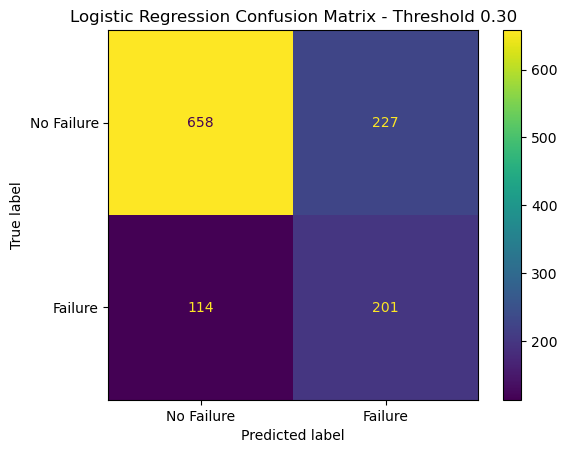

In [98]:
# Let's look at the final confusion matrix
# Before writing the final engineering recommendations, let's visualize exactly what the threshold 0.30 model is doing.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log_30)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix - Threshold 0.30")
plt.show()

# The key engineering result is:
# The model identified 201 of 315 actual failures, corresponding to approximately 63.8% recall, while producing 227 false-positive alerts.
# That's much more useful for discussing the model as a risk-screening tool rather than simply saying "the model has 71.6% accuracy."